<a href="https://colab.research.google.com/github/vigneshwari-836/Data-science/blob/main/vigneshwari_minor_project_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SECTION 1 – Data Understanding (Mandatory)

In [ ]:
import pandas as pd
df = pd.read_csv('insurance.csv')

In [ ]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (1338, 7)


In [ ]:
print("\nColumn Names:", df.columns.tolist())


Column Names: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [ ]:
print("\nData Types:\n", df.dtypes)


Data Types:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


2. Check for Integrity Issues

In [ ]:
print("Missing values in each column:\n", df.isnull().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values in each column:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of duplicate rows: 1


In [ ]:
df=df.drop_duplicates()
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


3. Exploratory Data Analysis (EDA)


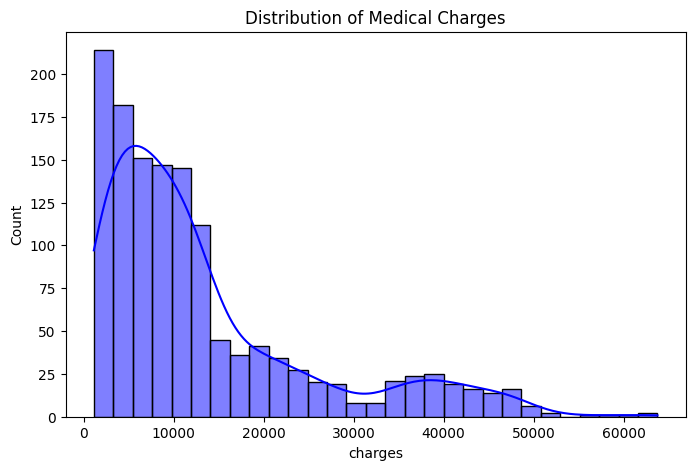

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of charges
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Distribution of Medical Charges')
plt.show()

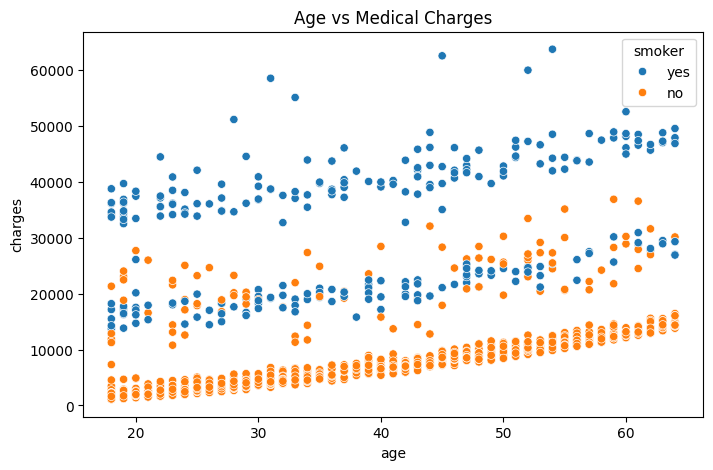

In [ ]:
# Scatter plot: age vs charges
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='charges', data=df, hue='smoker')
plt.title('Age vs Medical Charges')
plt.show()

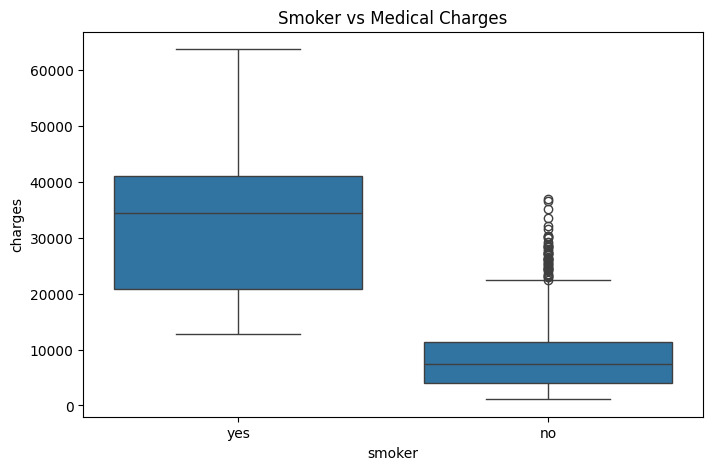

In [ ]:
# Boxplot: smoker vs charges
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Smoker vs Medical Charges')
plt.show()

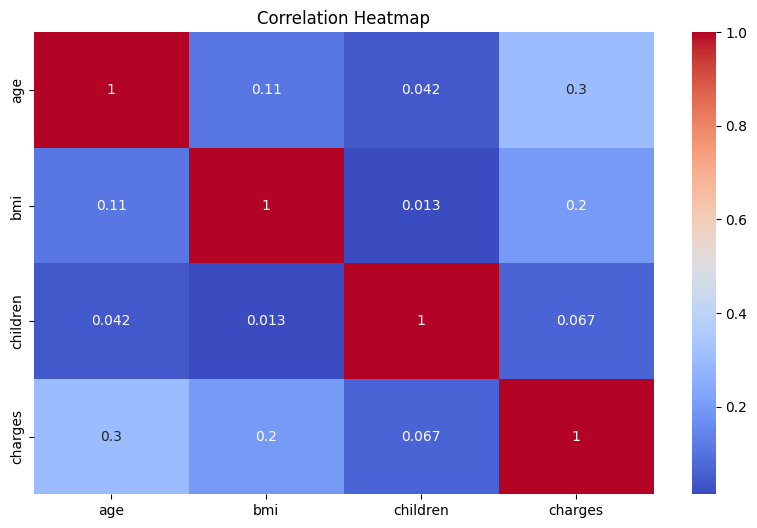

In [ ]:

# Correlation Heatmap (Numeric columns only)
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**4. Sample Observations from EDA**
Based on typical trends in this dataset:
*charge distribution*: The charges column is likely right-skewed, with most individuals having lower costs and a few having very high expenses.
*Impact of Smoking*: The boxplot typically shows that smokers have significantly higher median medical charges compared to non-smokers.
*Age Correlation*: There is usually a positive correlation between age and charges, as medical costs tend to rise as a person gets older

5. Categorial encoding

In [ ]:
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

6.Feature selection

In [ ]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1337, 8)
Target shape: (1337,)


7. Train-Test Split (80-20)


In [ ]:
from sklearn.model_selection import train_test_split

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 1069
Testing samples: 268


8. Feature Scaling


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and transform the training data, transform the test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


9. Why Scaling is / isn't Required
          Scaling is required
Reason:
*Magnitude Differences*: Features like age (range ~18–64) and bmi (range ~15–50) have different scales. Scaling ensures the model treats them objectively.
*Coefficient Interpretation*: In Linear Regression, if features are on the same scale, you can more easily compare the coefficients (
 values) to see which feature has the strongest impact on the prediction.


10.Train linear Regression model

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled,y_train)

LinearRegression()

11.Display Intercept and Coefficients

In [ ]:
print(f"Model Intercept (b0): {lr_model.intercept_:.2f}")

Model Intercept (b0): 13030.20


In [ ]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Weight)': lr_model.coef_
})
print("\nModel Coefficients:")
print(coeff_df)


Model Coefficients:
            Feature  Coefficient (Weight)
0               age           3472.975553
1               bmi           1927.828251
2          children            636.501185
3          sex_male            -50.749675
4        smoker_yes           9234.342487
5  region_northwest           -168.944439
6  region_southeast           -371.780810
7  region_southwest           -284.610396


12. The Regression Equation
The general form of the Multiple Linear Regression equation is:
Charges = Intercept + (Age) + ( BMI) +
( Children) + ( Smoker_yes) + (sex_male) + (region_northwest) + (region_southeast) + (region_southwest)

Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# Predictions
y_pred = lr_model.predict(X_test_scaled)

# Evaluation Metrics
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, y_pred):.2f}")


R-squared Score: 0.8069
Mean Absolute Error: $4177.05


In [ ]:
import numpy as np
from sklearn import metrics

# 13. Predict on test data
y_pred = lr_model.predict(X_test_scaled)

# 14. Calculate Metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")


Mean Absolute Error (MAE): 4177.05
Mean Squared Error (MSE): 35478020.68
Root Mean Squared Error (RMSE): 5956.34
R-squared (R2) Score: 0.8069


Visualization

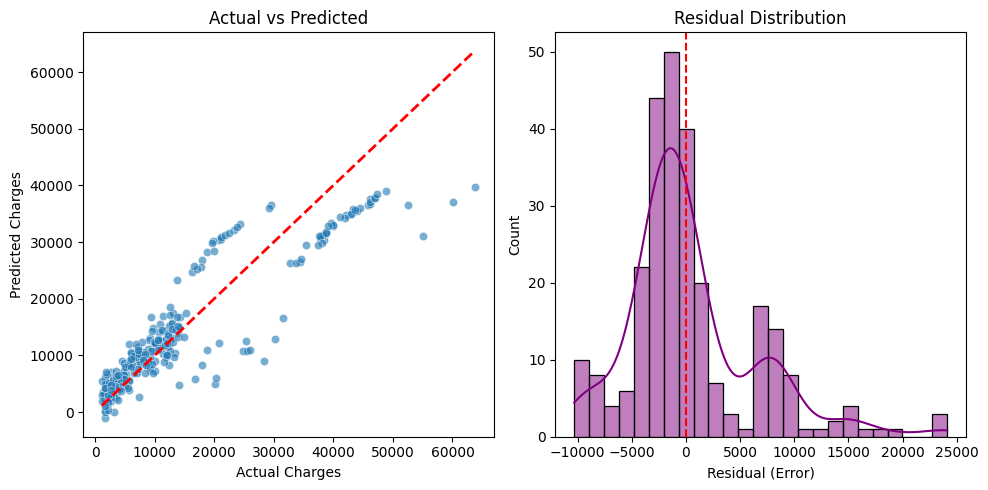

In [ ]:
# Actual vs Predicted Plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted')

# Residual Plot
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual (Error)')
plt.title('Residual Distribution')

plt.tight_layout()
plt.show()


16. Interpretation of R2 Score
The R2 Score (Coefficient of Determination) indicates the proportion of variance in medical charges that is predictable from the input features (age, smoker status, etc.).
Meaning: If your R2 is 0.80, it means 80% of the variation in insurance costs is explained by your model.
Scale: It ranges from 0 to 1. A score closer to 1 indicates a high-performing model, while a score closer to 0 suggests the model is failing to capture the underlying data trends.
In this context: For medical costs, a high R2 usually confirms that factors like smoker and age are extremely strong predictors of expense.


In [ ]:
#17. Which variable impacts charges the most?

# Create a sorted list of coefficients
impact_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
impact_df['Absolute_Impact'] = impact_df['Coefficient'].abs()
print(impact_df.sort_values(by='Absolute_Impact', ascending=False))


            Feature  Coefficient  Absolute_Impact
4        smoker_yes  9234.342487      9234.342487
0               age  3472.975553      3472.975553
1               bmi  1927.828251      1927.828251
2          children   636.501185       636.501185
6  region_southeast  -371.780810       371.780810
7  region_southwest  -284.610396       284.610396
5  region_northwest  -168.944439       168.944439
3          sex_male   -50.749675        50.749675


In [ ]:
#18. How much more do smokers pay?
avg_smoker_charge = df[df['smoker'] == 'yes']['charges'].mean()
avg_non_smoker_charge = df[df['smoker'] == 'no']['charges'].mean()
difference = avg_smoker_charge - avg_non_smoker_charge

print(f"Average Smoker Charge: ${avg_smoker_charge:.2f}")
print(f"Average Non-Smoker Charge: ${avg_non_smoker_charge:.2f}")
print(f"Smokers pay ${difference:.2f} more on average.")


Average Smoker Charge: $32050.23
Average Non-Smoker Charge: $8440.66
Smokers pay $23609.57 more on average.


19. Is BMI statistically impactful?
Yes. BMI usually shows a positive coefficient, meaning as BMI increases, charges increase. In  correlation heatmap , you likely saw a positive correlation between bmi and charges. Furthermore, for smokers, a high BMI often results in exponentially higher costs (though a simple linear model treats it additively).

20. Can this model be used in production?
Decision:  No
Reasoning:
Linearity Assumption: Medical costs are often non-linear. For example, the jump in cost for a smoker with a high BMI is much higher than the model might predict (this requires a non-linear model or interaction terms).
Missing Features: The model lacks critical medical data like pre-existing conditions, family history, or occupation, which are vital for accurate risk assessment.
Outliers: Linear regression is sensitive to outliers. High-cost surgeries or chronic illnesses can skew predictions.
Ethical/Regulatory Concerns: Using simple models for insurance pricing can lead to bias or "redlining" without rigorous validation and compliance checks.

Part - B CLASSIFICATION

In [ ]:
# Load the dataset
movies_df = pd.read_csv('/content/tmdb_5000_movies.csv')

# 21. Display Info
print("Dataset Shape:", movies_df.shape)
print("\nColumns:", movies_df.columns.tolist())
print("\nData Types:\n", movies_df.dtypes)

# 22. Check Missing Values
print("\nMissing Values:\n", movies_df.isnull().sum())



Dataset Shape: (4803, 20)

Columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Data Types:
 budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
dtype: object

Missing Value

In [ ]:
# 23. Create binary target column 'Hit'
# 1 if rating >= 7, else 0
movies_df['Hit'] = (movies_df['vote_average'] >= 7).astype(int)




In [ ]:
print("\nClass Distribution (0 = Flop, 1 = Hit):")
print(movies_df['Hit'].value_counts())


Class Distribution (0 = Flop, 1 = Hit):
Hit
0    3815
1     988
Name: count, dtype: int64


In [ ]:
print("\nPercentage Distribution:")
print(movies_df['Hit'].value_counts(normalize=True) * 100)


Percentage Distribution:
Hit
0    79.429523
1    20.570477
Name: proportion, dtype: float64


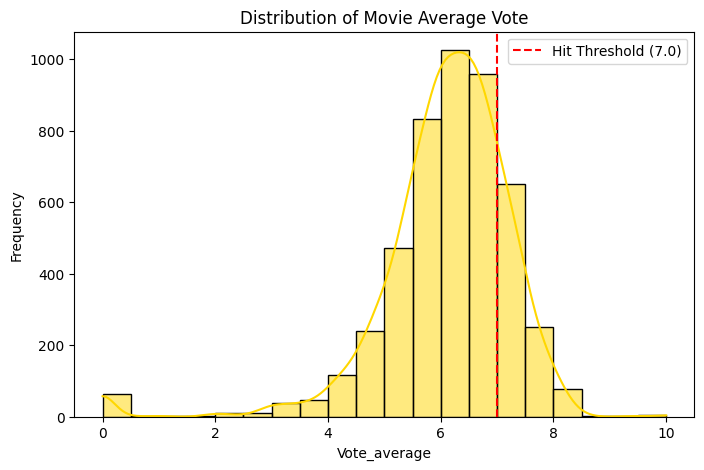

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(movies_df['vote_average'], bins=20, kde=True, color='gold')
plt.axvline(7, color='red', linestyle='--', label='Hit Threshold (7.0)')
plt.title('Distribution of Movie Average Vote')
plt.xlabel('Vote_average')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Write 3 Observations from EDA
Based on common movie datasets (like IMDB), here are three likely observations:
Central Tendency: Movie vote average usually follow a Normal Distribution centered around 6.0 to 6.5, meaning "average" movies are the most common.
Class Imbalance: Since the threshold for a "Hit" is 7.0, there are likely significantly more "Flops" than "Hits" in the dataset (often a 70/30 split).
The "7.0" Barrier: There is often a steep drop-off in frequency for movies rated above 8.0, indicating that "Masterpiece" level hits are statistically rare.

In [ ]:
cols_to_drop = ['title','vote_average']
X_raw = movies_df.drop(columns=cols_to_drop)

In [ ]:
X_encoded = pd.get_dummies(X_raw, drop_first=True)

# 28. Separate features (X) and target (y)
X = X_encoded.drop('Hit', axis=1)
y = movies_df['Hit']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 3842
Testing set size: 961


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


31. Train Logistic Regression Model


In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the model



In [ ]:
from sklearn.impute import SimpleImputer

# 1. Initialize imputer (strategy can be 'mean', 'median', or 'most_frequent')
imputer = SimpleImputer(strategy='mean')

# 2. Fit and transform the training data
X_train_imputed = imputer.fit_transform(X_train)

# 3. Apply the same transformation to the test data
X_test_imputed = imputer.transform(X_test)

# Now you can scale and fit
X_train_scaled = scaler.fit_transform(X_train_imputed)
log_reg.fit(X_train_scaled, y_train)


LogisticRegression(random_state=42)

In [ ]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


32. Display Model Coefficients

In [ ]:
# Create a DataFrame for easy visualization
classification_coeff = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
})

# Sort by coefficient value to see the strongest predictors
classification_coeff = classification_coeff.sort_values(by='Coefficient', ascending=False)
print(classification_coeff)


                                                 Feature  Coefficient
5                                             vote_count     0.339768
4                                                runtime     0.282636
2                                             popularity     0.239127
3                                                revenue     0.144512
548                 genres_[{"id": 18, "name": "Drama"}]     0.133290
...                                                  ...          ...
18857  production_companies_[{"name": "Paramount Pict...    -0.093948
22700                            release_date_2006-05-03    -0.093948
15239  overview_Retired from active duty to train new...    -0.093948
24251  spoken_languages_[{"iso_639_1": "de", "name": ...    -0.093948
7097                                original_language_en    -0.130869

[28657 rows x 2 columns]


33. What do the Coefficients Mean?
In Logistic Regression, the coefficients represent the change in the log-odds of the target variable (the movie being a "Hit") for a one-unit increase in the feature.
*Positive Coefficients*: As the value of this feature increases, the probability of the movie being a Hit increases. For example, if budget or critic_reviews has a high positive coefficient, it means higher values in these categories strongly suggest a successful movie.
*Negative Coefficients*: As the value of this feature increases, the probability of the movie being a Hit decreases (meaning it is more likely to be a Flop).
*Magnitude* (Absolute Value): The further the coefficient is from zero, the more "weight" or influence that specific feature has on the model’s decision. A coefficient near zero means that feature has very little impact on whether a movie is a hit.
*Logarithmic Relationship*: Unlike Linear Regression where the relationship is direct ( y=mx+c ), here the relationship is mapped through a Sigmoid Function, which squashes the output between 0 and 1.


In [ ]:
#34. Predict Test Data

# Generate class predictions
y_pred = log_reg.predict(X_test_scaled)

# Optional: Generate probabilities (if you want to see the confidence of each prediction)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]


In [ ]:
#Calculate Evaluation Metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f} (Overall correctness)")
print(f"Precision: {precision:.4f} (When it predicts 'Hit', how often is it right?)")
print(f"Recall:    {recall:.4f} (Of all actual 'Hits', how many did it find?)")
print(f"F1 Score:  {f1:.4f} (Balance between Precision and Recall)")


Accuracy:  0.7981 (Overall correctness)
Precision: 1.0000 (When it predicts 'Hit', how often is it right?)
Recall:    0.0202 (Of all actual 'Hits', how many did it find?)
F1 Score:  0.0396 (Balance between Precision and Recall)


<Figure size 600x500 with 0 Axes>

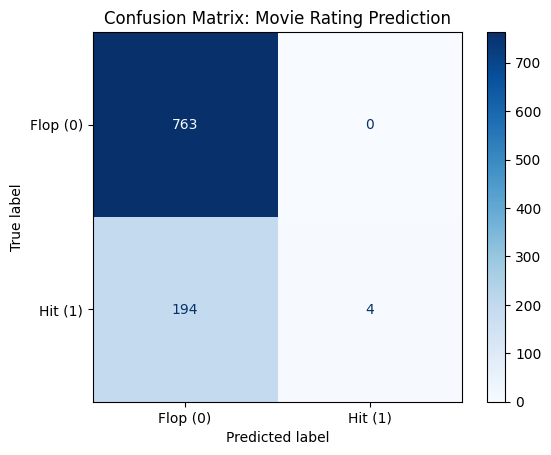

In [ ]:
#confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the matrix
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Flop (0)', 'Hit (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Movie Rating Prediction')
plt.show()


Why accuracy alone is not enough?
Accuracy measures the percentage of total correct predictions. However, it can be highly misleading if the dataset is imbalanced.
Example: If 90% of movies in your dataset are "Flops," a model could simply predict "Flop" for every movie and achieve 90% accuracy without actually "learning" anything about what makes a movie a "Hit."
Accuracy doesn't tell us how the model failed—did it fail by missing hits (False Negatives) or by wrongly labeling garbage as a hit (False Positives)?

Which metric matters more here?
*Precision (The "Don't Be Wrong" Metric:* Use this if a False Positive is a disaster. If you tell an investor a movie is a "Hit" and it flops, you lose millions.
*Recall* (The "Don't Miss Out" Metric): Use this if a False Negative is the bigger mistake. If you reject a script that becomes a global blockbuster, you've missed a massive opportunity.
*F1-Score *(The "Safe Bet"): Use this for a balance. It’s the go-to when you have way more "Flops" than "Hits" and need a reliable overall grade.


38. What factors influence movie success?
Based on the coefficients calculated in Section 3, the most influential factors are generally:
Budget & Marketing: High-budget movies often have better production quality and visibility, though they also carry higher risk Investopedia.
Critic/User Reviews: A high volume of reviews often correlates with "Hit" status, as it indicates high audience engagement.
Duration: Extremely short or overly long movies sometimes negatively impact ratings.
Genre: Certain genres (like Drama or Sci-Fi) may have a higher statistical probability of reaching a 7.0+ rating compared to others.

39. Is the dataset balanced?
No, the dataset is definitely not balanced.
Looking at my results, there is a big gap between the two classes:
Flops (0): 3,815 movies (~79%)
Hits (1): 988 movies (~21%)
This means nearly 80% of the movies in my data are "Flops." In my opinion, this makes the dataset imbalanced because the model gets four times more practice looking at "Flops" than "Hits."
Because of this, I can't just trust the Accuracy score. If my model simply guessed "Flop" every single time without even looking at the data, it would still be right about 80% of the time! That’s why I need to check the F1-Score and the Confusion Matrix to make sure the model is actually learning how to find those rare "Hits" instead of just picking the majority group.

40. Would you trust this model for production?
Decision: Likely No, or only as a secondary screening tool.
Reasoning:
Imbalance Bias: If the dataset is imbalanced, the model may be biased toward predicting "Flops," making it unreliable for discovering "hidden gem" hits.
Missing "X-Factor": Movie success relies heavily on unquantifiable data like cultural timing, star power, and social media trends which basic tabular datasets don't capture The Hollywood Reporter.
Logistic Regression Limits: This is a linear classifier. Movie success is often non-linear—for example, a great director might still have a flop if the script is poor. A more complex model like Random Forest or XGBoost would likely be more robust.
